## Import Libraries

In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from tqdm import tqdm
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report,
    confusion_matrix, f1_score, log_loss, precision_recall_curve,
    precision_score, recall_score, auc, roc_curve
)
from sklearn.metrics import classification_report


## Load dataset


In [3]:
df_train = pd.read_csv('../data/FEwithMerchants/FE_train_downsampled_1to10_with_merchants.csv')
df_val = pd.read_csv('../data/FEwithMerchants/FE_validation_with_merchants.csv')
df_test = pd.read_csv('../data/FEwithMerchants/FE_test_with_merchants.csv')

In [4]:
# to check
df_train.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'nameDest',
       'oldbalanceDest', 'isFlaggedFraud', 'isFraud',
       'amount_to_oldbalanceOrg', 'day', 'avgAmountToDest',
       'maxAmountReceived', 'stdAmountReceived', 'std_to_mean_ratio',
       'avgAmountPerType', 'p95AmountPerType', 'typeHighValueFlag',
       'amountLog', 'amountBucket', 'fraudProbabilityByAmountBin', 'totalSent',
       'meanSent', 'stdSent', 'numSent', 'totalReceived', 'meanReceived',
       'stdReceived', 'numReceived', 'hourOfDay', 'dayOfWeek', 'dayOfWeekName',
       'numUniqueDest', 'numUniqueOrig', 'transactionRecency',
       'transaction_sequence', 'sequence_frequency',
       'is_cashin_transfer_cashout', 'is_transfer_cashout',
       'is_cashin_transfer', 'is_cashout_transfer', 'is_transfer_transfer',
       'is_first_transfer', 'is_cashin_cashout', 'is_early_transaction',
       'sequence_count', 'pctForwarded24h', 'pairFrequency', 'pctUniqueDest',
       'pctUniqueOrig', 'sender_btwn'

## Data Processing
- Convert to categorical columns to ensure XGBoost handles categorical features correctly
- Feature selection

In [5]:
print("Converting categorical columns ...")
categorical_cols = [
    'type', 'hourOfDay', 'dayOfWeek', 'dayOfWeekName', 'transaction_sequence', 'isFlaggedFraud', 'typeHighValueFlag', 'amountBucket', 
]

for col in categorical_cols:
    # Combine categories from both train, val and test, to avoid unseen categories during inference 
    combined_cats = pd.Series(
        pd.concat([df_train[col], df_val[col], df_test[col]], axis=0).dropna().unique()
    )
    categories = sorted(combined_cats.unique())

    df_train[col] = pd.Categorical(df_train[col], categories=categories)
    df_val[col]   = pd.Categorical(df_val[col], categories=categories)
    df_test[col]  = pd.Categorical(df_test[col], categories=categories)

Converting categorical columns ...


In [6]:
# # selected features for all
selected_features = [
    # transaction-level features
    'step', 'type', 'hourOfDay', 'day', 'amountLog', 'dayOfWeek', 'amount', 
    'oldbalanceOrg', 'oldbalanceDest',
    'amount_to_oldbalanceOrg',
     
                
    # account-level features
    'meanSent', 
    'totalSent', 'stdSent', 'numSent', 
    'totalReceived',  'numReceived', 
    'stdReceived', 'meanReceived', 
    'maxAmountReceived', 'stdAmountReceived', 'std_to_mean_ratio', 
    'avgAmountToDest', 
    'pctForwarded24h', 'pairFrequency', 'pctUniqueDest', 'pctUniqueOrig', 

    # transaction pattern features 
    'transaction_sequence', 'sequence_frequency', 'transactionRecency', 'typeHighValueFlag', 
    'is_early_transaction',  'sequence_count',
    'is_transfer_cashout', 'is_cashin_transfer', 'is_cashout_transfer', 'is_cashin_transfer_cashout',
    'is_transfer_transfer', 'is_first_transfer', 'is_cashin_cashout', 

    # centrality features
    'sender_btwn', 'receiver_btwn', 'btwn_diff', 
    'sender_outdeg_amt', 'sender_indeg_amt', 'receiver_outdeg_amt', 'receiver_indeg_amt',
    'sender_outdeg_cnt', 'sender_indeg_cnt', 'receiver_outdeg_cnt', 'receiver_indeg_cnt', 
    'outdeg_amt_diff', 'indeg_amt_diff',
    'outdeg_cnt_diff', 'indeg_cnt_diff' 
]

# selected for 1to5 model with merchants
# selected_features = ['amount_to_oldbalanceOrg', 'sequence_frequency', 'transaction_sequence', 'meanReceived', 'oldbalanceDest', 'oldbalanceOrg', 'avgAmountToDest', 'type', 'meanSent', 'totalSent', 'hourOfDay', 'receiver_indeg_amt', 'maxAmountReceived', 'indeg_amt_diff', 'stdReceived', 'amount', 'totalReceived', 'stdAmountReceived', 'amountLog']

# selected for 1to10 model with merchants
# selected_features = ['type', 'amount_to_oldbalanceOrg', 'sequence_frequency', 'oldbalanceDest', 'oldbalanceOrg', 'hourOfDay', 'amountLog', 'avgAmountToDest', 'transaction_sequence', 'meanSent', 'totalSent', 'receiver_indeg_amt', 'indeg_cnt_diff', 'amount', 'stdAmountReceived']

In [7]:
print("Processing training set ...")
Xtrain, ytrain = df_train[selected_features].copy(), df_train["isFraud"].astype(int)

print("Processing validation set ...")
Xval, yval = df_val[selected_features].copy(), df_val["isFraud"].astype(int)

print("Processing test set ...")
Xtest, ytest = df_test[selected_features].copy(), df_test["isFraud"].astype(int)

print("Done!")
Xtrain.columns

Processing training set ...
Processing validation set ...
Processing test set ...
Done!


Index(['step', 'type', 'hourOfDay', 'day', 'amountLog', 'dayOfWeek', 'amount',
       'oldbalanceOrg', 'oldbalanceDest', 'amount_to_oldbalanceOrg',
       'meanSent', 'totalSent', 'stdSent', 'numSent', 'totalReceived',
       'numReceived', 'stdReceived', 'meanReceived', 'maxAmountReceived',
       'stdAmountReceived', 'std_to_mean_ratio', 'avgAmountToDest',
       'pctForwarded24h', 'pairFrequency', 'pctUniqueDest', 'pctUniqueOrig',
       'transaction_sequence', 'sequence_frequency', 'transactionRecency',
       'typeHighValueFlag', 'is_early_transaction', 'sequence_count',
       'is_transfer_cashout', 'is_cashin_transfer', 'is_cashout_transfer',
       'is_cashin_transfer_cashout', 'is_transfer_transfer',
       'is_first_transfer', 'is_cashin_cashout', 'sender_btwn',
       'receiver_btwn', 'btwn_diff', 'sender_outdeg_amt', 'sender_indeg_amt',
       'receiver_outdeg_amt', 'receiver_indeg_amt', 'sender_outdeg_cnt',
       'sender_indeg_cnt', 'receiver_outdeg_cnt', 'receiver_indeg_

## XGBoost Classifier
### Hyperparameter Tuning

To improve model performance, a **random search** over XGBoost hyperparameters was conducted using a predefined parameter grid.  
The search randomly samples 20 parameter combinations (`n_iter = 20`) from ranges covering model complexity, learning rate, regularization, and subsampling ratios.

For each sampled parameter set:
1. A model was trained on the training set with the parameter combinations.
2. Performance was evaluated on the validation set using **PR-AUC** (Area Under Precision-Recall Curve)
3. Results were stored and sorted to identify the best-performing configuration.


In [8]:
param_grid = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.005, 0.01, 0.05],
    'n_estimators': [300, 600, 1000],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'gamma': [0.1, 0.2, 0.5, 0.8, 1],
    'reg_alpha': [0, 0.05, 0.1, 0.5, 1],
    'reg_lambda': [0.5, 1, 2, 3],
}

# n_iter = 3
n_iter = 20
param_list = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=42))
results = []
best_xgb, best_params, best_score = None, None, -1

for params in tqdm(param_list, desc="Random Search Hyperparameter Tuning"):
    print("Training model with params:", params)
    model = XGBClassifier(
        **params,
        random_state=42,
        enable_categorical=True,
        eval_metric="aucpr",
        n_jobs=-1
    )

    # Evaluate on validation set 
    model.fit(Xtrain, 
            ytrain,
            eval_set=[(Xval, yval)],
            verbose=False)

    yval_pred = model.predict_proba(Xval)[:, 1]
    pr_auc = average_precision_score(yval, yval_pred)

    results.append({
        **params,
        "pr_auc": pr_auc,
    })
    print(f"Validation PR-AUC: {pr_auc:.6f}")

    # Save the best model during training
    if pr_auc > best_score:
        best_score = pr_auc
        best_xgb = model
        best_params = params

df_results = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
print(df_results.head(5))

Random Search Hyperparameter Tuning:   0%|          | 0/20 [00:00<?, ?it/s]

Training model with params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 600, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.6}


Random Search Hyperparameter Tuning:   5%|▌         | 1/20 [02:53<54:55, 173.43s/it]

Validation PR-AUC: 0.965247
Training model with params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.005, 'gamma': 0.1, 'colsample_bytree': 0.6}


Random Search Hyperparameter Tuning:  10%|█         | 2/20 [04:14<35:47, 119.33s/it]

...

Validation PR-AUC: 0.961781
Training model with params: {'subsample': 1.0, 'reg_lambda': 3, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}


Random Search Hyperparameter Tuning:  95%|█████████▌| 19/20 [49:58<02:31, 151.06s/it]

Validation PR-AUC: 0.967146
Training model with params: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 1, 'colsample_bytree': 1.0}


Random Search Hyperparameter Tuning: 100%|██████████| 20/20 [52:50<00:00, 158.55s/it]

Validation PR-AUC: 0.958237
    subsample  reg_lambda  reg_alpha  n_estimators  min_child_weight  \
9         1.0         3.0       0.10           600                 3   
18        1.0         3.0       0.50           300                 1   
13        1.0         0.5       0.05           600                 5   
1         0.8         2.0       0.10           300                10   
0         1.0         1.0       1.00           600                10   

    max_depth  learning_rate  gamma  colsample_bytree    pr_auc  
9           5          0.050    0.5               0.6  0.968684  
18          9          0.050    0.1               0.6  0.967146  
13          5          0.005    0.1               0.6  0.966400  
1           5          0.005    0.1               0.6  0.965419  
0           3          0.050    0.5               0.6  0.965247  


### Choosing the Best Model
The model with the **highest PR-AUC score** was identified as the best model, since PR-AUC is more informative for imbalanced classification problems


In [9]:
print("=== Best Model from Random Search Hyperparameter Tuning ===")
print(f"Best PR-AUC: {best_score:.6f}")
for k, v in best_params.items():
    print(f"{k:<20}: {v}")

=== Best Model from Random Search Hyperparameter Tuning ===
Best PR-AUC: 0.968684
subsample           : 1.0
reg_lambda          : 3
reg_alpha           : 0.1
n_estimators        : 600
min_child_weight    : 3
max_depth           : 5
learning_rate       : 0.05
gamma               : 0.5
colsample_bytree    : 0.6


## Feature Importance & Feature Selection

A feature importance plot was generated to visualize the relative influence of each variable on the model’s predictions.

Subsequently, a feature selection step was performed by ranking all features based on their importance scores and calculating their cumulative contribution. Features collectively accounting for 95% of the total model importance were retained as the most informative subset.

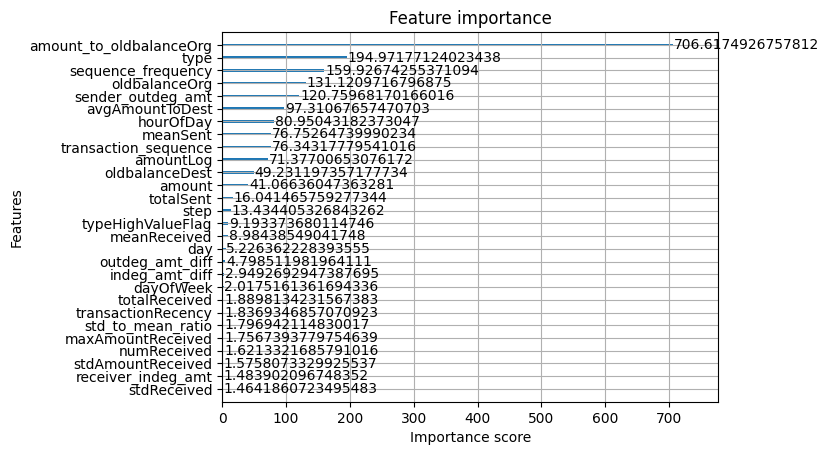

In [10]:
xgb.plot_importance(best_xgb, importance_type='gain')
plt.show()

In [11]:
all_features = pd.DataFrame({'feature': Xtrain.columns})
importance_dict = best_xgb.get_booster().get_score(importance_type='gain')

feature_importance_df = pd.DataFrame({
    'feature': list(importance_dict.keys()),
    'importance': list(importance_dict.values())
})

# Merge with all features, fill missing with 0
feature_importance_df = all_features.merge(feature_importance_df, on='feature', how='left').fillna(0)

# Sort by importance
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

# Calculate cumulative importance
feature_importance_df['cumulative_importance'] = (
    feature_importance_df['importance'].cumsum() / feature_importance_df['importance'].sum()
)

print(feature_importance_df.head(20))

top_features = feature_importance_df[
    feature_importance_df['cumulative_importance'] <= 0.95
]['feature'].tolist()

print(f"\nSelected {len(top_features)} features explaining 95% of model importance")
print(top_features)

                    feature  importance  cumulative_importance
9   amount_to_oldbalanceOrg  706.617493               0.375361
1                      type  194.971771               0.478932
27       sequence_frequency  159.926743               0.563887
7             oldbalanceOrg  131.120972               0.633539
42        sender_outdeg_amt  120.759682               0.697688
21          avgAmountToDest   97.310677               0.749380
2                 hourOfDay   80.950432               0.792382
10                 meanSent   76.752647               0.833153
26     transaction_sequence   76.343178               0.873708
4                 amountLog   71.377007               0.911624
8            oldbalanceDest   49.231197               0.937776
6                    amount   41.066360               0.959590
11                totalSent   16.041466               0.968112
0                      step   13.434405               0.975248
29        typeHighValueFlag    9.193374               0

## Threshold tuning
Threshold tuning is done on validation set. We will choose threshold based on highest F1-score.

In [12]:
yval_pred = best_xgb.predict_proba(Xval)[:, 1]
pr_val, rec_val, thr_val = precision_recall_curve(yval, yval_pred)
f1_val = 2 * (pr_val * rec_val) / (pr_val + rec_val + 1e-8)

best_thr = thr_val[np.argmax(f1_val)]
print(f"Best Threshold: {best_thr:.4f}")

Best Threshold: 0.9770


## Model Evaluation

To assess the performance of the final XGBoost model, both training and test set predictions were evaluated using Precision–Recall (PR) metrics, which are more informative than accuracy in imbalanced classification settings such as fraud detection.

A secondary plot was generated to examine how Precision, Recall, and F1-score change across different classification thresholds, enabling better selection of an optimal cutoff that balances false positives and false negatives according to business needs.

Train PR-AUC : 0.9996762540319082
Test PR-AUC : 0.9682554647928198


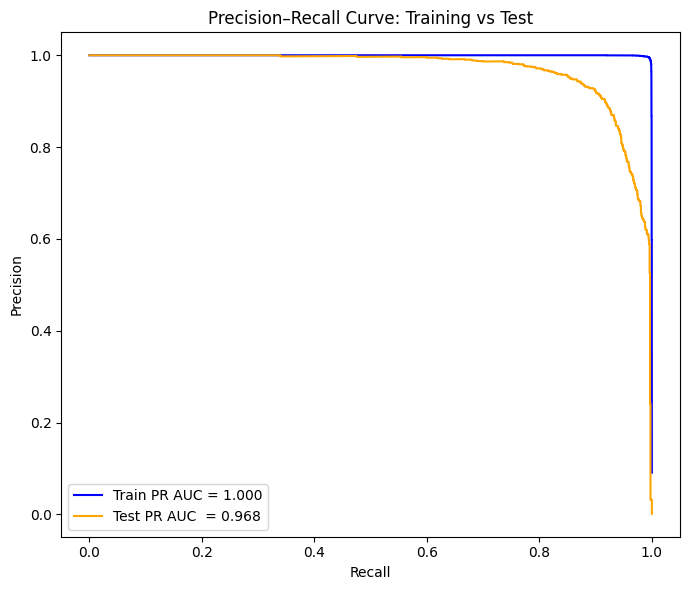

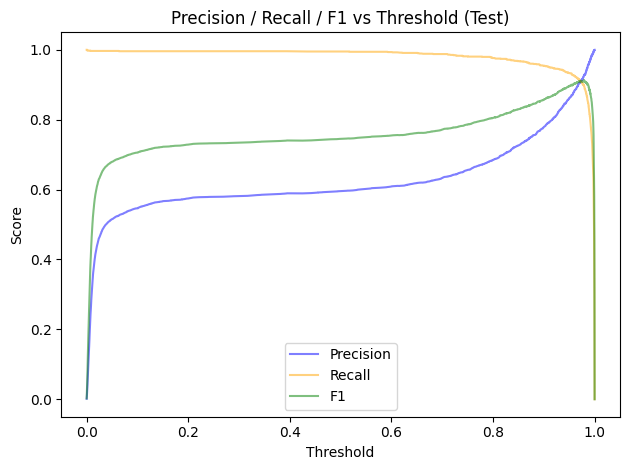

In [13]:
ytrain_proba = best_xgb.predict_proba(Xtrain)[:, 1]
ytest_proba = best_xgb.predict_proba(Xtest)[:, 1]
print("Train PR-AUC :", average_precision_score(ytrain, ytrain_proba))
print("Test PR-AUC :", average_precision_score(ytest, ytest_proba))

ytrain_true = ytrain.astype(int)
ytest_true = ytest.astype(int)

# --- Precision–Recall Curves ---
prec_train, rec_train, thr_pr_train = precision_recall_curve(ytrain_true, ytrain_proba)
prec_test,  rec_test,  thr_pr_test  = precision_recall_curve(ytest_true,  ytest_proba)
ap_train = average_precision_score(ytrain_true, ytrain_proba)
ap_test  = average_precision_score(ytest_true,  ytest_proba)

plt.figure(figsize=(7,6))
plt.plot(rec_train, prec_train, label=f"Train PR AUC = {ap_train:.3f}", color="blue")
plt.plot(rec_test,  prec_test,  label=f"Test PR AUC  = {ap_test:.3f}", color="orange")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve: Training vs Test")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# --- Precision / Recall / F1 vs Threshold ---
thr_test  = np.r_[0.0, thr_pr_test]
f1_test  = 2 * (prec_test  * rec_test)  / np.clip(prec_test  + rec_test,  1e-12, None)

plt.plot(thr_test, prec_test, label="Precision", color="blue", alpha=0.5)
plt.plot(thr_test, rec_test,  label="Recall", color="orange", alpha=0.5)
plt.plot(thr_test, f1_test,   label="F1", color="green", alpha=0.5)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold (Test)")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Using best_thr from validation set
ytest_pred = (ytest_proba >= best_thr).astype(int)
print("Test Classification Report:")
print(classification_report(ytest, ytest_pred))

Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    953161
           1       0.92      0.90      0.91      1232

    accuracy                           1.00    954393
   macro avg       0.96      0.95      0.96    954393
weighted avg       1.00      1.00      1.00    954393



## Save the Model

In [15]:
os.makedirs('../models/XGB/', exist_ok=True)
best_xgb.save_model('../models/XGB/best_xgb_1to10_all.json')

## Generate Plots
Run the following sections first before running `Generate Plots`
- `Import Libraries`
- `Load dataset`
- `Data Processing`

In [16]:
# Create plots directory if it doesn't exist
plots_dir = "../plots"
os.makedirs(plots_dir, exist_ok=True)

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [17]:
# Load the saved model - used for Ensemble method
plot_xgb = XGBClassifier()
plot_xgb.load_model('../models/XGB/best_xgb_1to10_all.json')
ytest_proba = plot_xgb.predict_proba(Xtest)[:, 1]
ytest = ytest.astype(int)

thr = 0.3104 # threshold at maximum F1
ytest_pred = (ytest_proba > thr).astype(int) 


### 1. Confusion Matrix

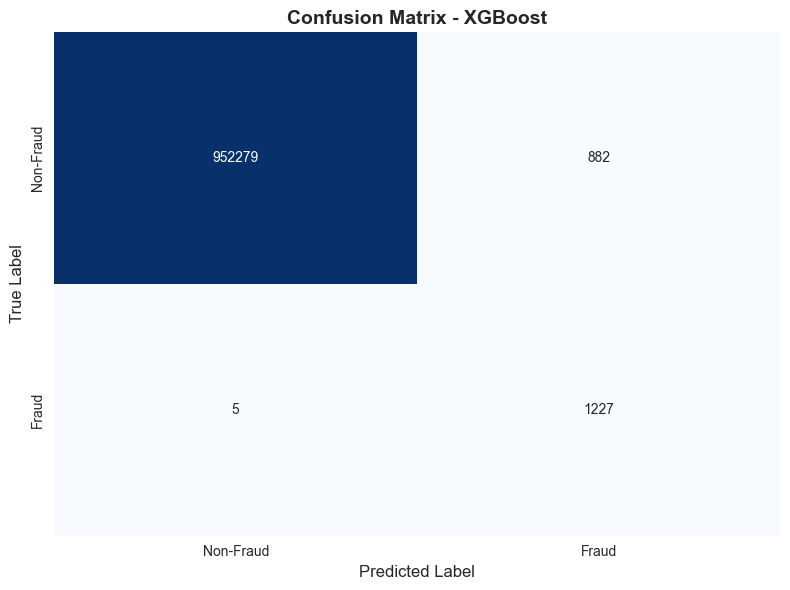

✓ Saved: xgboost_confusion_matrix.png


In [18]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(ytest, ytest_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Non-Fraud', 'Fraud'], 
            yticklabels=['Non-Fraud', 'Fraud'])
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'xgboost_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: xgboost_confusion_matrix.png")

### 2. ROC Curve

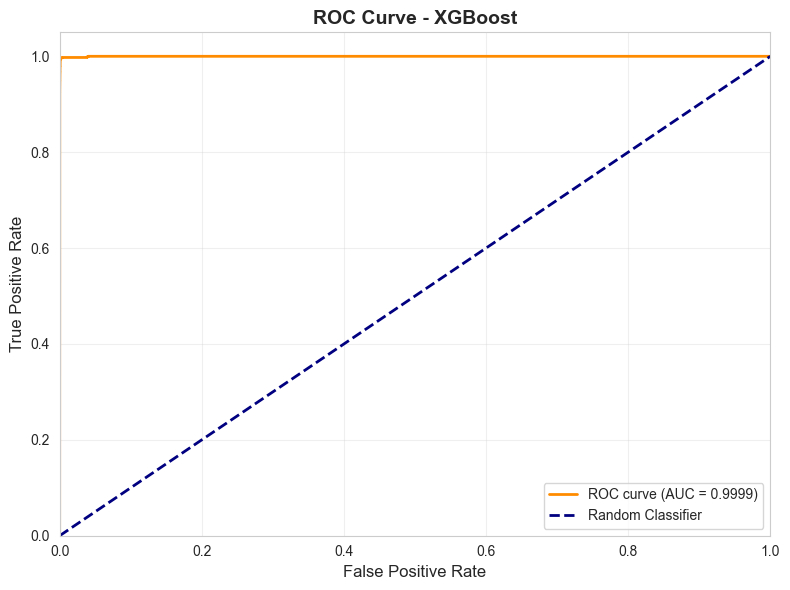

✓ Saved: xgboost_roc_curve.png


In [19]:
# ROC Curve
fpr, tpr, _ = roc_curve(ytest, ytest_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - XGBoost', fontsize=14, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'xgboost_roc_curve.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: xgboost_roc_curve.png")

### 3. Precision-Recall Curve

Precision-Recall AUC: 0.9683


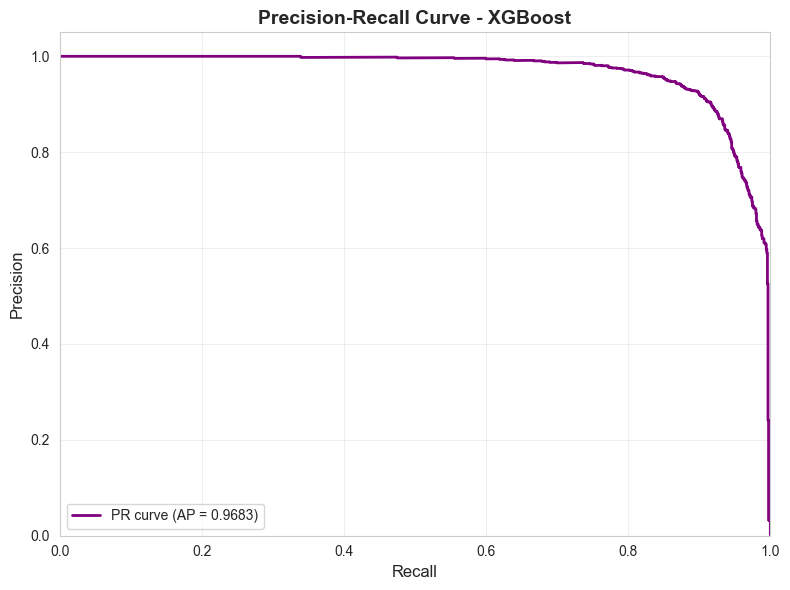

✓ Saved: xgboost_pr_curve.png


In [20]:
pr_auc = average_precision_score(ytest, ytest_proba)
print(f"Precision-Recall AUC: {pr_auc:.4f}")

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(ytest, ytest_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {pr_auc:.4f})')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve - XGBoost', fontsize=14, fontweight='bold')
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'xgboost_pr_curve.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: xgboost_pr_curve.png")

### 4. Feature Importance

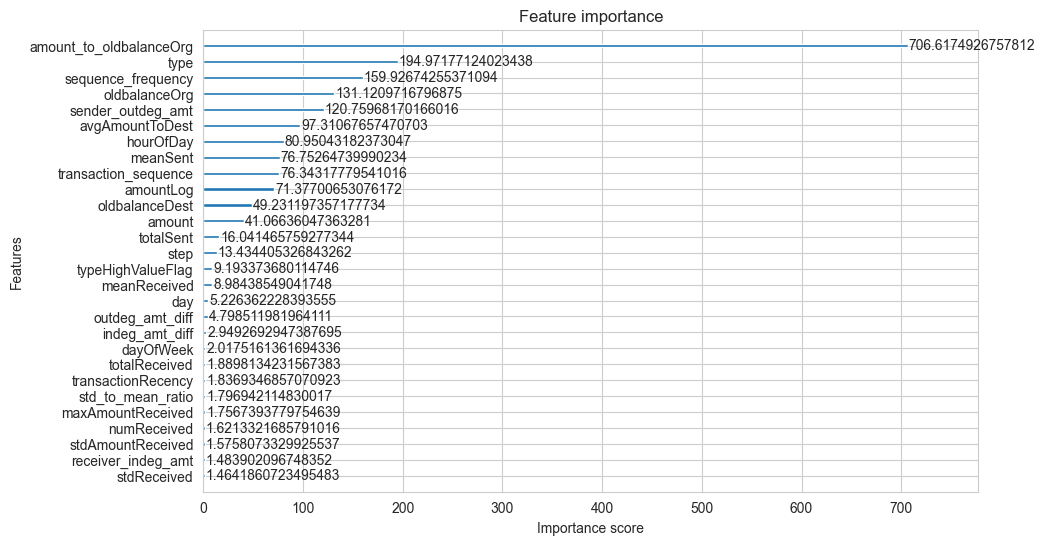

✓ Saved: xgboost_feature_importance.png


In [21]:
xgb.plot_importance(plot_xgb, importance_type='gain')
plt.savefig(os.path.join(plots_dir, 'xgboost_feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: xgboost_feature_importance.png")

### Save metrics to CSV

In [22]:
f1 = f1_score(ytest, ytest_pred, zero_division=0)

# Save F1 and PR-AUC to CSV for Streamlit
metrics_data = {
    'Metric': ['F1-Score', 'PR-AUC'],
    'Value': [
        f1,
        pr_auc,
    ]
}

metrics_df = pd.DataFrame(metrics_data)
metrics_df.to_csv(os.path.join(plots_dir, 'xgboost_metrics.csv'), index=False)
print("✓ Saved: xgboost_metrics.csv (F1-Score, PR-AUC)")
print("\nMetrics Summary:")
print(metrics_df.to_string(index=False))

✓ Saved: xgboost_metrics.csv (F1-Score, PR-AUC)

Metrics Summary:
  Metric    Value
F1-Score 0.734511
  PR-AUC 0.968255
